# 06 — Object-Constrained Part-Query Alignment

## Goal

Previous experiments studied whether explicit spatial coordinates improve
text-conditioned part segmentation.

This notebook addresses a different limitation:

> How does the text query actually correspond to individual DINOv2 patches?

DINOv2 produces dense visual features:

[B, 384, 16, 16]

CLIP produces one text representation:

[B, 512]

Previous models broadcast the text representation across the entire spatial
feature map and relied on the segmentation decoder to learn the visual-language
correspondence implicitly.

In this notebook we explicitly calculate a patch-query similarity map.

For every DINO patch:

visual patch representation
        ↕
CLIP part-query representation

This produces:

[B, 1, 16, 16]

which represents coarse query relevance.

Example:

query = "wheel"

high relevance → patches likely related to wheels
low relevance  → unrelated patches

The relevance map is constrained by the parent-object mask.

---

## Experiments

### 1. mask_baseline

DINO + CLIP + parent-object mask

Alignment channel = zero

UV channels = zero

### 2. alignment_mask

DINO + CLIP + parent-object mask + learned part-query alignment

UV channels = zero

### 3. alignment_relative_uv

DINO + CLIP + parent-object mask + learned part-query alignment + relative U/V

---

## Main Questions

1. Does explicit part-query alignment improve segmentation?
2. Does the alignment map correctly highlight the requested part?
3. Does object-relative U/V remain complementary after semantic alignment?
4. Does alignment help more on unseen parent-object categories?

DINOv2 and CLIP remain frozen.

In [32]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [33]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [34]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [35]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_COMMON_DIM = 128
TEXT_DECODER_DIM = 32

MASK_THRESHOLD = 0.5

ALIGNMENT_TEMPERATURE = 0.10
ALIGNMENT_LOSS_WEIGHT = 0.20

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "part_query_alignment"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output:", OUTPUT_ROOT)

Device: cuda
AMP: True
Output: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/part_query_alignment


In [36]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [37]:
raw_train_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_val_dataset = PascalPart116Dataset(
    split="validation_seen"
)

raw_test_seen_dataset = PascalPart116Dataset(
    split="test_seen"
)

raw_test_unseen_dataset = PascalPart116Dataset(
    split="test_unseen"
)

print("Train:", len(raw_train_dataset))
print("Validation:", len(raw_val_dataset))
print("Test seen:", len(raw_test_seen_dataset))
print("Test unseen:", len(raw_test_unseen_dataset))

Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


In [38]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [39]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(height * scale),
    )

    new_w = max(
        1,
        round(width * scale),
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,

        "top": top,
        "bottom": bottom,

        "left": left,
        "right": right,

        "scale": scale,
    }

In [40]:
def preprocess_image(
    image,
    target_size=224,
):

    image = (
        image.float()
        / 255.0
    )

    _, h, w = image.shape

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

In [41]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:

        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return (
        padded > 0.5
    )

In [42]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:

        mask = (
            object_mask.squeeze(0)
        )

    else:

        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    u = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(
        mask
    )

    if len(xs) == 0:

        return (
            u.unsqueeze(0),
            v.unsqueeze(0),
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    x_denom = max(
        int(x_max - x_min),
        1,
    )

    y_denom = max(
        int(y_max - y_min),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u[
        ys,
        xs,
    ] = u_values

    v[
        ys,
        xs,
    ] = v_values

    return (
        u.unsqueeze(0),
        v.unsqueeze(0),
    )

In [43]:
class AlignmentDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = (
            image_size
        )


    def __len__(self):

        return len(
            self.base_dataset
        )


    def __getitem__(
        self,
        index,
    ):

        sample = (
            self.base_dataset[index]
        )

        (
            display_image,
            image,
            resize_info,
        ) = preprocess_image(
            sample["image"],
            self.image_size,
        )


        object_mask = preprocess_mask(
            sample["object_mask"],
            resize_info,
            preserve_positive=True,
        )


        part_mask = preprocess_mask(
            sample["part_mask"],
            resize_info,
            preserve_positive=True,
        )


        overlap = (
            object_mask
            & part_mask
        )


        if (
            part_mask.any()
            and not overlap.any()
        ):

            object_mask = (
                object_mask
                | part_mask
            )


        part_mask = (
            part_mask
            & object_mask
        )


        relative_u, relative_v = (
            create_relative_uv(
                object_mask
            )
        )


        return {
            "sample_id": (
                sample["sample_id"]
            ),

            "image_id": (
                sample["image_id"]
            ),

            "image": image,

            "display_image": (
                display_image
            ),

            "object_mask": (
                object_mask.float()
            ),

            "part_mask": (
                part_mask.float()
            ),

            "relative_u": (
                relative_u
            ),

            "relative_v": (
                relative_v
            ),

            "query": (
                sample["query"]
            ),

            "object_name": (
                sample["object_name"]
            ),

            "part_name": (
                sample["part_name"]
            ),

            "full_part_name": (
                sample["full_part_name"]
            ),

            "part_id": (
                sample["part_id"]
            ),

            "evaluation_split": (
                sample["evaluation_split"]
            ),
        }

In [44]:
train_dataset = AlignmentDataset(
    "train_seen",
    IMAGE_SIZE,
)

val_dataset = AlignmentDataset(
    "validation_seen",
    IMAGE_SIZE,
)

test_seen_dataset = AlignmentDataset(
    "test_seen",
    IMAGE_SIZE,
)

test_unseen_dataset = AlignmentDataset(
    "test_unseen",
    IMAGE_SIZE,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Seen test:", len(test_seen_dataset))
print("Unseen test:", len(test_unseen_dataset))

Train: 32698
Validation: 3708
Seen test: 3371
Unseen test: 1586


In [45]:
sample = train_dataset[0]

for key, value in sample.items():

    if torch.is_tensor(value):

        print(
            f"{key:20s}",
            tuple(value.shape),
            value.dtype,
        )

    else:

        print(
            f"{key:20s}",
            value,
        )

sample_id            train:2008_000002:part_115
image_id             2008_000002
image                (3, 224, 224) torch.float32
display_image        (3, 224, 224) torch.float32
object_mask          (1, 224, 224) torch.float32
part_mask            (1, 224, 224) torch.float32
relative_u           (1, 224, 224) torch.float32
relative_v           (1, 224, 224) torch.float32
query                screen
object_name          tvmonitor
part_name            screen
full_part_name       tvmonitor's screen
part_id              115
evaluation_split     seen


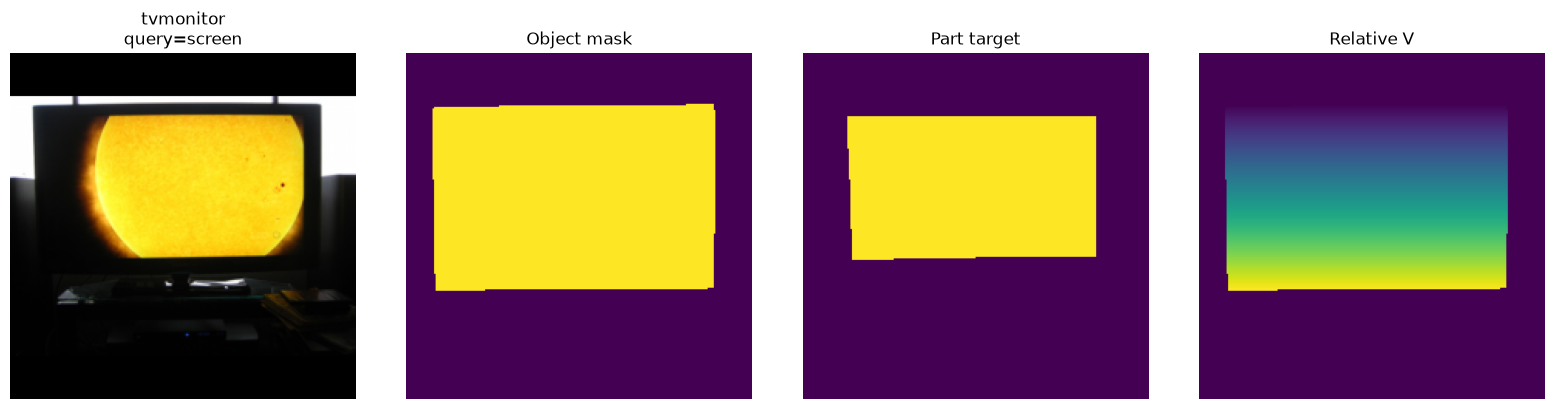

In [46]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    sample["display_image"]
    .permute(1, 2, 0)
)

axes[0].set_title(
    f"{sample['object_name']}\n"
    f"query={sample['query']}"
)

axes[1].imshow(
    sample["object_mask"]
    .squeeze()
)

axes[1].set_title(
    "Object mask"
)

axes[2].imshow(
    sample["part_mask"]
    .squeeze()
)

axes[2].set_title(
    "Part target"
)

axes[3].imshow(
    sample["relative_v"]
    .squeeze(),
    vmin=0,
    vmax=1,
)

axes[3].set_title(
    "Relative V"
)

for ax in axes:

    ax.axis("off")

plt.tight_layout()
plt.show()

In [47]:
PIN_MEMORY = (
    DEVICE.type == "cuda"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

In [48]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(
    DEVICE
)

dino.eval()

for p in dino.parameters():

    p.requires_grad = False


print(
    "DINOv2 loaded and frozen."
)

DINOv2 loaded and frozen.


Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main


In [49]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = (
    clip_model
    .to(DEVICE)
)

clip_model.eval()

for p in clip_model.parameters():

    p.requires_grad = False


print(
    "CLIP loaded and frozen."
)

CLIP loaded and frozen.


In [50]:
class TextEmbeddingCache:

    def __init__(
        self,
        model,
        tokenizer,
        device,
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.cache = {}


    @torch.no_grad()
    def _encode_missing(
        self,
        queries,
    ):

        missing = sorted(
            {
                q
                for q in queries
                if q not in self.cache
            }
        )

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = (
            self.tokenizer(
                prompts
            )
            .to(self.device)
        )

        embeddings = (
            self.model.encode_text(
                tokens
            )
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for q, embedding in zip(
            missing,
            embeddings,
        ):

            self.cache[q] = (
                embedding
                .detach()
                .cpu()
            )


    def __call__(
        self,
        queries,
    ):

        self._encode_missing(
            queries
        )

        batch = torch.stack(
            [
                self.cache[q]
                for q in queries
            ]
        )

        return batch.to(
            self.device,
            non_blocking=True,
        )

In [51]:
text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

# Part-Query Alignment

DINO produces:

[B, 384, 16, 16]

We first project visual features:

384 → 128

giving:

[B, 128, 16, 16]

CLIP produces:

[B, 512]

We project the text embedding:

512 → 128

giving:

[B, 128]

Both representations are L2-normalized.

For every DINO patch we calculate cosine similarity with the text query:

S(i,j) = cosine(F(i,j), T)

This produces:

[B, 1, 16, 16]

For query `"wheel"`:

high S → patch looks relevant to "wheel"

low S → patch is less relevant

The map is then constrained by the parent-object mask.

The same projected visual and textual features are also used by the
segmentation decoder.

This means the alignment experiment does not require a completely separate
large network.

In [77]:
class PartQueryAlignmentSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_common_dim=128,
        text_decoder_dim=32,
        temperature=0.10,
    ):

        super().__init__()

        assert mode in {
            "mask_baseline",
            "alignment_mask",
            "alignment_relative_uv",
        }

        self.mode = mode
        self.temperature = temperature

        # ==========================================
        # Frozen DINOv2
        # ==========================================

        self.dino = dino_encoder

        for p in self.dino.parameters():
            p.requires_grad = False

        # ==========================================
        # Visual projection
        # DINO: 384 -> 128
        # ==========================================

        self.visual_projection = nn.Conv2d(
            384,
            visual_dim,
            kernel_size=1,
        )

        # ==========================================
        # Text projection
        # CLIP: 512 -> 128
        # ==========================================

        self.text_projection = nn.Sequential(
            nn.Linear(
                512,
                text_common_dim,
            ),
            nn.GELU(),
        )

        # For decoder:
        # 128 -> 32
        self.text_decoder_projection = nn.Linear(
            text_common_dim,
            text_decoder_dim,
        )

        # ==========================================
        # Decoder
        #
        # visual     = 128
        # text       = 32
        # object     = 1
        # U,V        = 2
        # alignment  = 1
        #
        # total = 164
        # ==========================================

        fusion_dim = (
            visual_dim
            + text_decoder_dim
            + 1
            + 2
            + 1
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                128,
            ),

            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )

    # ==========================================
    # Keep DINO in eval mode
    # ==========================================

    def train(
        self,
        mode=True,
    ):

        super().train(mode)

        self.dino.eval()

        return self

    # ==========================================
    # DINO feature extraction
    # ==========================================

    @torch.no_grad()
    def extract_dino_features(
        self,
        images,
    ):

        output = self.dino.forward_features(
            images
        )

        tokens = output[
            "x_norm_patchtokens"
        ]

        # tokens:
        # [B, 256, 384]

        b, n, c = tokens.shape

        grid = int(
            n ** 0.5
        )

        features = (
            tokens
            .transpose(1, 2)
            .reshape(
                b,
                c,
                grid,
                grid,
            )
        )

        # [B,384,16,16]

        return features

    # ==========================================
    # DINO <-> CLIP alignment
    # ==========================================

    def compute_alignment(
        self,
        visual,
        text_common,
    ):

        # visual:
        # [B,128,16,16]

        visual_normalized = F.normalize(
            visual,
            dim=1,
        )

        # text_common:
        # [B,128]

        text_normalized = F.normalize(
            text_common,
            dim=1,
        )

        text_spatial = (
            text_normalized[
                :,
                :,
                None,
                None,
            ]
        )

        # cosine similarity
        cosine_similarity = (
            visual_normalized
            * text_spatial
        ).sum(
            dim=1,
            keepdim=True,
        )

        # [B,1,16,16]

        alignment_logits = (
            cosine_similarity
            / self.temperature
        )

        alignment_probability = torch.sigmoid(
            alignment_logits
        )

        return (
            alignment_logits,
            alignment_probability,
        )

    # ==========================================
    # Forward
    # ==========================================

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        relative_u,
        relative_v,
    ):

        # ------------------------------------------
        # 1. DINO
        # ------------------------------------------

        dino_features = (
            self.extract_dino_features(
                images
            )
        )

        # [B,384,16,16]

        # ------------------------------------------
        # 2. Visual projection
        # ------------------------------------------

        visual = self.visual_projection(
            dino_features
        )

        # [B,128,16,16]

        # ------------------------------------------
        # 3. Text projection
        # ------------------------------------------

        text_common = self.text_projection(
            text_embeddings
        )

        # [B,128]

        text_decoder = (
            self.text_decoder_projection(
                text_common
            )
        )

        # [B,32]

        text_map = (
            text_decoder[
                :,
                :,
                None,
                None,
            ]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        # [B,32,16,16]

        # ------------------------------------------
        # 4. Query alignment
        # ------------------------------------------

        (
            alignment_logits,
            alignment_probability,
        ) = self.compute_alignment(
            visual,
            text_common,
        )

        spatial_size = (
            visual.shape[-2:]
        )

        # ------------------------------------------
        # 5. Object mask
        # ------------------------------------------

        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )

        alignment_map = (
            alignment_probability
            * mask_low
        )

        # ------------------------------------------
        # 6. Relative geometry
        # ------------------------------------------

        u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        u_low = (
            u_low
            * mask_low
        )

        v_low = (
            v_low
            * mask_low
        )

        # ------------------------------------------
        # 7. Controlled experiment modes
        # ------------------------------------------

        if self.mode == "mask_baseline":

            alignment_input = (
                torch.zeros_like(
                    alignment_map
                )
            )

            u_input = (
                torch.zeros_like(
                    u_low
                )
            )

            v_input = (
                torch.zeros_like(
                    v_low
                )
            )


        elif self.mode == "alignment_mask":

            alignment_input = (
                alignment_map
            )

            u_input = (
                torch.zeros_like(
                    u_low
                )
            )

            v_input = (
                torch.zeros_like(
                    v_low
                )
            )


        elif (
            self.mode
            == "alignment_relative_uv"
        ):

            alignment_input = (
                alignment_map
            )

            u_input = (
                u_low
            )

            v_input = (
                v_low
            )

        # ------------------------------------------
        # 8. Fusion
        # ------------------------------------------

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                u_input,
                v_input,
                alignment_input,
            ],
            dim=1,
        )

        # [B,164,16,16]

        # ------------------------------------------
        # 9. Decoder
        # ------------------------------------------

        logits_low = self.decoder(
            fused
        )

        # [B,1,16,16]

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # [B,1,224,224]

        # ------------------------------------------
        # 10. Auxiliary outputs
        # ------------------------------------------

        aux = {

            "alignment_logits":
                alignment_logits,

            "alignment_probability":
                alignment_probability,

            "alignment_map":
                alignment_map,

            "object_mask_low":
                mask_low,
        }

        return (
            logits,
            aux,
        )

In [78]:
MODES = [
    "mask_baseline",
    "alignment_mask",
    "alignment_relative_uv",
]


models_test = {}

for mode in MODES:

    models_test[mode] = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
    )

In [79]:
parameter_counts = {}

for mode, model in (
    models_test.items()
):

    parameter_counts[mode] = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


parameter_counts

{'mask_baseline': 400801,
 'alignment_mask': 400801,
 'alignment_relative_uv': 400801}

In [80]:
assert (
    len(
        set(
            parameter_counts.values()
        )
    )
    == 1
)

print(
    "All experiment modes have identical "
    "trainable parameter counts."
)

All experiment modes have identical trainable parameter counts.


In [81]:
del models_test

In [82]:
batch = next(
    iter(train_loader)
)

images = (
    batch["image"]
    .to(DEVICE)
)

object_masks = (
    batch["object_mask"]
    .to(DEVICE)
)

relative_u = (
    batch["relative_u"]
    .to(DEVICE)
)

relative_v = (
    batch["relative_v"]
    .to(DEVICE)
)

text_embeddings = (
    text_encoder(
        batch["query"]
    )
)

print("Images:", images.shape)

print(
    "Text:",
    text_embeddings.shape
)

Images: torch.Size([16, 3, 224, 224])
Text: torch.Size([16, 512])


In [83]:
test_model = (
    PartQueryAlignmentSegmenter(
        dino_encoder=dino,
        mode="alignment_mask",
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
    )
    .to(DEVICE)
)

with torch.no_grad():

    logits, aux = (
        test_model(
            images,
            text_embeddings,
            object_masks,
            relative_u,
            relative_v,
        )
    )


print(
    "Segmentation logits:",
    logits.shape
)

print(
    "Alignment logits:",
    aux[
        "alignment_logits"
    ].shape
)

print(
    "Alignment map:",
    aux[
        "alignment_map"
    ].shape
)

Segmentation logits: torch.Size([16, 1, 224, 224])
Alignment logits: torch.Size([16, 1, 16, 16])
Alignment map: torch.Size([16, 1, 16, 16])


## Alignment Supervision

DINO operates on a 16 × 16 patch grid.

The part masks exist at 224 × 224 resolution.

We therefore need a coarse target for the alignment map.

A tiny part could disappear if ordinary nearest-neighbour downsampling were
used.

Instead we use adaptive max pooling.

If any pixel belonging to the requested part appears inside a DINO patch,
that patch receives a positive alignment target.

Therefore:

224 × 224 part mask

→ adaptive max pooling

→ 16 × 16 coarse part-relevance target

This preserves small parts much better than ordinary nearest-neighbour
downsampling.

In [84]:
def create_alignment_targets(
    part_mask,
    object_mask,
    output_size,
):

    target_low = (
        F.adaptive_max_pool2d(
            part_mask,
            output_size=output_size,
        )
    )

    valid_low = (
        F.adaptive_max_pool2d(
            object_mask,
            output_size=output_size,
        )
    )

    target_low = (
        target_low
        * valid_low
    )

    return (
        target_low,
        valid_low,
    )

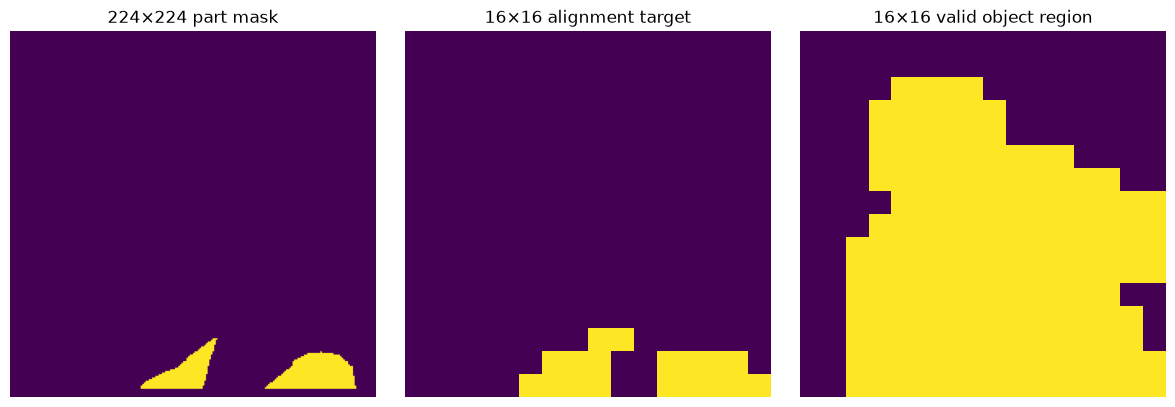

In [85]:
target_low, valid_low = (
    create_alignment_targets(
        batch[
            "part_mask"
        ].to(DEVICE),

        object_masks,

        output_size=(
            16,
            16,
        ),
    )
)


idx = 0

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)

axes[0].imshow(
    batch[
        "part_mask"
    ][idx]
    .squeeze()
)

axes[0].set_title(
    "224×224 part mask"
)

axes[1].imshow(
    target_low[
        idx,
        0
    ].cpu()
)

axes[1].set_title(
    "16×16 alignment target"
)

axes[2].imshow(
    valid_low[
        idx,
        0
    ].cpu()
)

axes[2].set_title(
    "16×16 valid object region"
)

for ax in axes:

    ax.axis("off")

plt.tight_layout()
plt.show()

In [86]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):

    probabilities = (
        torch.sigmoid(logits)
        .flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        probabilities
        * targets
    ).sum(
        dim=1
    )

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return (
        1 - dice
    ).mean()

In [87]:
def segmentation_loss(
    logits,
    targets,
):

    bce = (
        F.binary_cross_entropy_with_logits(
            logits,
            targets,
        )
    )

    dice = dice_loss(
        logits,
        targets,
    )

    return {
        "seg_total": (
            bce + dice
        ),

        "seg_bce": bce,

        "seg_dice": dice,
    }

In [88]:
def masked_alignment_dice_loss(
    logits,
    target,
    valid_mask,
    eps=1e-6,
):

    probability = (
        torch.sigmoid(
            logits
        )
        * valid_mask
    )

    target = (
        target
        * valid_mask
    )

    probability = (
        probability.flatten(1)
    )

    target = (
        target.flatten(1)
    )

    intersection = (
        probability
        * target
    ).sum(
        dim=1
    )

    denominator = (
        probability.sum(dim=1)
        + target.sum(dim=1)
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return (
        1 - dice
    ).mean()

In [89]:
def masked_alignment_bce(
    logits,
    target,
    valid_mask,
):

    loss_map = (
        F.binary_cross_entropy_with_logits(
            logits,
            target,
            reduction="none",
        )
    )

    weighted = (
        loss_map
        * valid_mask
    )

    return (
        weighted.sum()
        /
        valid_mask.sum().clamp_min(
            1.0
        )
    )

In [90]:
def alignment_loss(
    alignment_logits,
    part_mask,
    object_mask,
):

    output_size = (
        alignment_logits.shape[-2:]
    )

    target_low, valid_low = (
        create_alignment_targets(
            part_mask,
            object_mask,
            output_size,
        )
    )


    bce = masked_alignment_bce(
        alignment_logits,
        target_low,
        valid_low,
    )


    dice = (
        masked_alignment_dice_loss(
            alignment_logits,
            target_low,
            valid_low,
        )
    )


    return {
        "align_total": (
            bce + dice
        ),

        "align_bce": bce,

        "align_dice": dice,

        "target_low": target_low,

        "valid_low": valid_low,
    }

In [91]:
def compute_total_loss(
    mode,
    logits,
    aux,
    part_mask,
    object_mask,
):

    seg = segmentation_loss(
        logits,
        part_mask,
    )


    align = alignment_loss(
        aux[
            "alignment_logits"
        ],
        part_mask,
        object_mask,
    )


    if mode == "mask_baseline":

        total = (
            seg["seg_total"]
        )

    else:

        total = (
            seg["seg_total"]
            +
            ALIGNMENT_LOSS_WEIGHT
            * align["align_total"]
        )


    return {
        "total": total,

        "seg_total": (
            seg["seg_total"]
        ),

        "seg_bce": (
            seg["seg_bce"]
        ),

        "seg_dice": (
            seg["seg_dice"]
        ),

        "align_total": (
            align["align_total"]
        ),

        "align_bce": (
            align["align_bce"]
        ),

        "align_dice": (
            align["align_dice"]
        ),

        "alignment_target": (
            align["target_low"]
        ),
    }

In [92]:
targets = (
    batch["part_mask"]
    .to(DEVICE)
)

losses = compute_total_loss(
    mode="alignment_mask",
    logits=logits,
    aux=aux,
    part_mask=targets,
    object_mask=object_masks,
)

for key, value in losses.items():

    if torch.is_tensor(value):

        if value.ndim == 0:

            print(
                key,
                value.item(),
            )

        else:

            print(
                key,
                value.shape,
            )

total 1.9486503601074219
seg_total 1.6487627029418945
seg_bce 0.6983829140663147
seg_dice 0.9503798484802246
align_total 1.4994385242462158
align_bce 0.7389997243881226
align_dice 0.7604387998580933
alignment_target torch.Size([16, 1, 16, 16])


In [93]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    union = (
        predictions
        | targets
    ).sum(
        dim=1
    ).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [94]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    return (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

In [95]:
@torch.no_grad()
def batch_alignment_iou(
    alignment_logits,
    part_mask,
    object_mask,
    threshold=0.5,
    eps=1e-6,
):

    target_low, valid_low = (
        create_alignment_targets(
            part_mask,
            object_mask,
            alignment_logits.shape[-2:],
        )
    )


    prediction = (
        torch.sigmoid(
            alignment_logits
        )
        >= threshold
    )


    prediction = (
        prediction
        & (valid_low >= 0.5)
    )


    target = (
        target_low >= 0.5
    )


    prediction = (
        prediction.flatten(1)
    )

    target = (
        target.flatten(1)
    )


    intersection = (
        prediction
        & target
    ).sum(
        dim=1
    ).float()


    union = (
        prediction
        | target
    ).sum(
        dim=1
    ).float()


    return (
        intersection + eps
    ) / (
        union + eps
    )

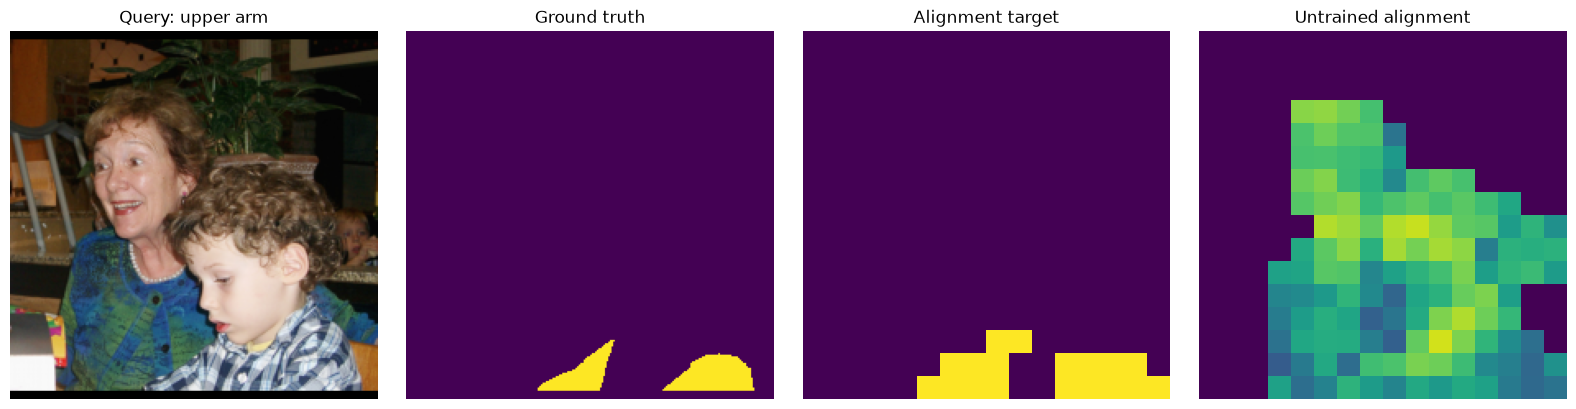

In [96]:
idx = 0

alignment_before = (
    aux[
        "alignment_map"
    ][idx, 0]
    .detach()
    .cpu()
)

alignment_target = (
    losses[
        "alignment_target"
    ][idx, 0]
    .detach()
    .cpu()
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    batch[
        "display_image"
    ][idx]
    .permute(1, 2, 0)
)

axes[0].set_title(
    f"Query: "
    f"{batch['query'][idx]}"
)

axes[1].imshow(
    batch[
        "part_mask"
    ][idx]
    .squeeze()
)

axes[1].set_title(
    "Ground truth"
)

axes[2].imshow(
    alignment_target
)

axes[2].set_title(
    "Alignment target"
)

axes[3].imshow(
    alignment_before,
    vmin=0,
    vmax=1,
)

axes[3].set_title(
    "Untrained alignment"
)

for ax in axes:

    ax.axis("off")

plt.tight_layout()
plt.show()

In [97]:
del test_model

if torch.cuda.is_available():

    torch.cuda.empty_cache()

In [98]:
debug_model = (
    PartQueryAlignmentSegmenter(
        dino_encoder=dino,
        mode="alignment_mask",
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
    )
    .to(DEVICE)
)


debug_optimizer = (
    torch.optim.AdamW(
        (
            p
            for p
            in debug_model.parameters()
            if p.requires_grad
        ),
        lr=1e-3,
    )
)

In [99]:
debug_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

debug_batch = next(
    iter(debug_loader)
)


debug_images = (
    debug_batch["image"]
    .to(DEVICE)
)

debug_objects = (
    debug_batch["object_mask"]
    .to(DEVICE)
)

debug_targets = (
    debug_batch["part_mask"]
    .to(DEVICE)
)

debug_u = (
    debug_batch["relative_u"]
    .to(DEVICE)
)

debug_v = (
    debug_batch["relative_v"]
    .to(DEVICE)
)

debug_text = text_encoder(
    debug_batch["query"]
)


print(
    debug_batch["query"]
)

['screen', 'torso', 'leg', 'body']


In [100]:
debug_total_losses = []
debug_alignment_losses = []

for step in range(200):

    debug_model.train()

    debug_optimizer.zero_grad(
        set_to_none=True
    )


    logits_debug, aux_debug = (
        debug_model(
            debug_images,
            debug_text,
            debug_objects,
            debug_u,
            debug_v,
        )
    )


    losses_debug = (
        compute_total_loss(
            mode="alignment_mask",
            logits=logits_debug,
            aux=aux_debug,
            part_mask=debug_targets,
            object_mask=debug_objects,
        )
    )


    losses_debug[
        "total"
    ].backward()


    debug_optimizer.step()


    debug_total_losses.append(
        losses_debug[
            "total"
        ].item()
    )

    debug_alignment_losses.append(
        losses_debug[
            "align_total"
        ].item()
    )


    if (
        step == 0
        or (step + 1) % 40 == 0
    ):

        print(
            f"Step {step+1:3d} | "
            f"Total "
            f"{losses_debug['total'].item():.4f} | "
            f"Alignment "
            f"{losses_debug['align_total'].item():.4f}"
        )

Step   1 | Total 1.7753 | Alignment 1.0225
Step  40 | Total 0.5468 | Alignment 0.0364
Step  80 | Total 0.5353 | Alignment 0.0104
Step 120 | Total 0.3725 | Alignment 0.0116
Step 160 | Total 0.3047 | Alignment 0.0081
Step 200 | Total 0.2611 | Alignment 0.0063


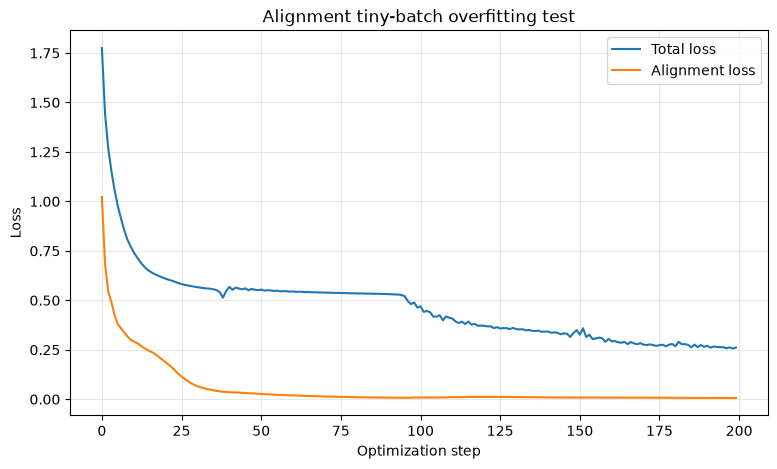

In [101]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    debug_total_losses,
    label="Total loss",
)

plt.plot(
    debug_alignment_losses,
    label="Alignment loss",
)

plt.xlabel(
    "Optimization step"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Alignment tiny-batch overfitting test"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

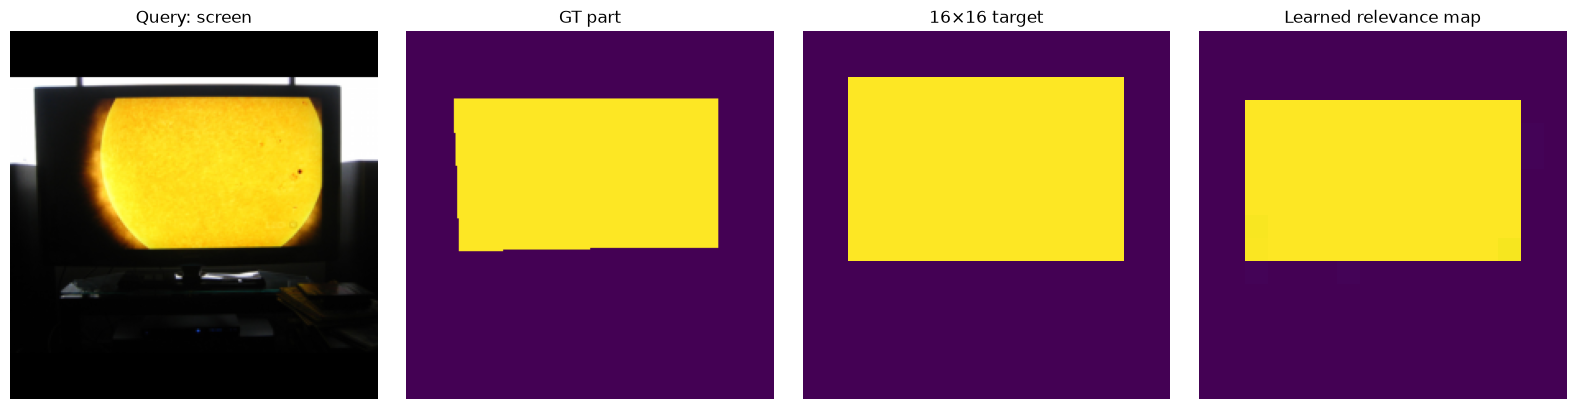

In [102]:
debug_model.eval()

with torch.no_grad():

    debug_logits, debug_aux = (
        debug_model(
            debug_images,
            debug_text,
            debug_objects,
            debug_u,
            debug_v,
        )
    )


debug_alignment = (
    debug_aux[
        "alignment_map"
    ][0, 0]
    .cpu()
)


debug_target_low, _ = (
    create_alignment_targets(
        debug_targets,
        debug_objects,
        (
            16,
            16,
        ),
    )
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    debug_batch[
        "display_image"
    ][0]
    .permute(1, 2, 0)
)

axes[0].set_title(
    f"Query: "
    f"{debug_batch['query'][0]}"
)

axes[1].imshow(
    debug_batch[
        "part_mask"
    ][0]
    .squeeze()
)

axes[1].set_title(
    "GT part"
)

axes[2].imshow(
    debug_target_low[
        0,
        0
    ].cpu()
)

axes[2].set_title(
    "16×16 target"
)

axes[3].imshow(
    debug_alignment,
    vmin=0,
    vmax=1,
)

axes[3].set_title(
    "Learned relevance map"
)

for ax in axes:

    ax.axis("off")

plt.tight_layout()
plt.show()

In [103]:
print(
    "Segmentation IoU:",
    batch_iou(
        debug_logits,
        debug_targets,
    ).mean().item()
)

print(
    "Alignment IoU:",
    batch_alignment_iou(
        debug_aux[
            "alignment_logits"
        ],
        debug_targets,
        debug_objects,
    ).mean().item()
)

Segmentation IoU: 0.689923882484436
Alignment IoU: 1.0


In [104]:
del debug_model
del debug_optimizer

if torch.cuda.is_available():

    torch.cuda.empty_cache()

In [105]:
def run_epoch(
    model,
    mode,
    loader,
    optimizer=None,
    scaler=None,
    max_batches=None,
):

    training = (
        optimizer is not None
    )

    if training:

        model.train()

    else:

        model.eval()


    totals = {
        "loss": 0.0,
        "seg_loss": 0.0,
        "align_loss": 0.0,
        "iou": 0.0,
        "dice": 0.0,
        "alignment_iou": 0.0,
    }

    total_samples = 0


    for batch_index, batch in enumerate(
        loader
    ):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):

            break


        images = (
            batch["image"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        objects = (
            batch["object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        targets = (
            batch["part_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_u = (
            batch["relative_u"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_v = (
            batch["relative_v"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        text_embeddings = (
            text_encoder(
                batch["query"]
            )
        )


        batch_size = (
            images.shape[0]
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits, aux = (
                    model(
                        images,
                        text_embeddings,
                        objects,
                        relative_u,
                        relative_v,
                    )
                )


                losses = (
                    compute_total_loss(
                        mode,
                        logits,
                        aux,
                        targets,
                        objects,
                    )
                )


            if training:

                if scaler is not None:

                    scaler.scale(
                        losses[
                            "total"
                        ]
                    ).backward()


                    scaler.unscale_(
                        optimizer
                    )


                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p
                            in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )


                    scaler.step(
                        optimizer
                    )

                    scaler.update()


                else:

                    losses[
                        "total"
                    ].backward()

                    optimizer.step()


        with torch.no_grad():

            ious = batch_iou(
                logits,
                targets,
                MASK_THRESHOLD,
            )

            dices = batch_dice(
                logits,
                targets,
                MASK_THRESHOLD,
            )

            alignment_ious = (
                batch_alignment_iou(
                    aux[
                        "alignment_logits"
                    ],
                    targets,
                    objects,
                )
            )


        totals["loss"] += (
            losses["total"].item()
            * batch_size
        )

        totals["seg_loss"] += (
            losses["seg_total"].item()
            * batch_size
        )

        totals["align_loss"] += (
            losses["align_total"].item()
            * batch_size
        )

        totals["iou"] += (
            ious.sum().item()
        )

        totals["dice"] += (
            dices.sum().item()
        )

        totals["alignment_iou"] += (
            alignment_ious.sum().item()
        )

        total_samples += (
            batch_size
        )


    return {
        key: (
            value / total_samples
        )
        for key, value in totals.items()
    }

In [106]:
def get_trainable_state(
    model,
):

    return {
        "visual_projection": (
            model.visual_projection
            .state_dict()
        ),

        "text_projection": (
            model.text_projection
            .state_dict()
        ),

        "text_decoder_projection": (
            model.text_decoder_projection
            .state_dict()
        ),

        "decoder": (
            model.decoder
            .state_dict()
        ),
    }

In [107]:
def load_trainable_state(
    model,
    checkpoint,
):

    state = checkpoint[
        "model_state"
    ]


    model.visual_projection.load_state_dict(
        state[
            "visual_projection"
        ]
    )


    model.text_projection.load_state_dict(
        state[
            "text_projection"
        ]
    )


    model.text_decoder_projection.load_state_dict(
        state[
            "text_decoder_projection"
        ]
    )


    model.decoder.load_state_dict(
        state[
            "decoder"
        ]
    )

In [108]:
def train_experiment(
    mode,
    epochs=20,
):

    seed_everything(
        SEED
    )


    experiment_dir = (
        OUTPUT_ROOT
        / mode
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    model = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
        .to(DEVICE)
    )


    optimizer = (
        torch.optim.AdamW(
            (
                p
                for p
                in model.parameters()
                if p.requires_grad
            ),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )
    )


    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )


    config = {
        "mode": mode,

        "seed": SEED,

        "image_size": IMAGE_SIZE,

        "epochs": epochs,

        "train_batch_size": (
            TRAIN_BATCH_SIZE
        ),

        "learning_rate": (
            LEARNING_RATE
        ),

        "weight_decay": (
            WEIGHT_DECAY
        ),

        "alignment_temperature": (
            ALIGNMENT_TEMPERATURE
        ),

        "alignment_loss_weight": (
            ALIGNMENT_LOSS_WEIGHT
        ),

        "visual_dim": (
            VISUAL_DIM
        ),

        "text_common_dim": (
            TEXT_COMMON_DIM
        ),

        "text_decoder_dim": (
            TEXT_DECODER_DIM
        ),
    }


    with open(
        experiment_dir
        / "config.json",
        "w",
    ) as f:

        json.dump(
            config,
            f,
            indent=2,
        )


    history = []

    best_val_iou = -1.0


    for epoch in range(
        1,
        epochs + 1,
    ):

        start = time.time()


        train_metrics = run_epoch(
            model,
            mode,
            train_loader,
            optimizer=optimizer,
            scaler=scaler,
        )


        with torch.no_grad():

            val_metrics = run_epoch(
                model,
                mode,
                val_loader,
            )


        scheduler.step(
            val_metrics["iou"]
        )


        elapsed = (
            time.time()
            - start
        )


        row = {
            "epoch": epoch,

            "train_loss": (
                train_metrics["loss"]
            ),

            "train_iou": (
                train_metrics["iou"]
            ),

            "train_alignment_iou": (
                train_metrics[
                    "alignment_iou"
                ]
            ),

            "val_loss": (
                val_metrics["loss"]
            ),

            "val_iou": (
                val_metrics["iou"]
            ),

            "val_dice": (
                val_metrics["dice"]
            ),

            "val_alignment_iou": (
                val_metrics[
                    "alignment_iou"
                ]
            ),

            "learning_rate": (
                optimizer
                .param_groups[0]["lr"]
            ),

            "seconds": elapsed,
        }


        history.append(
            row
        )


        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train IoU "
            f"{train_metrics['iou']:.4f} | "
            f"val IoU "
            f"{val_metrics['iou']:.4f} | "
            f"align IoU "
            f"{val_metrics['alignment_iou']:.4f} | "
            f"{elapsed:.1f}s"
        )


        checkpoint = {
            "epoch": epoch,

            "mode": mode,

            "model_state": (
                get_trainable_state(
                    model
                )
            ),

            "optimizer_state": (
                optimizer.state_dict()
            ),

            "scheduler_state": (
                scheduler.state_dict()
            ),

            "val_metrics": (
                val_metrics
            ),

            "config": (
                config
            ),
        }


        torch.save(
            checkpoint,
            experiment_dir
            / "last.pt",
        )


        if (
            val_metrics["iou"]
            > best_val_iou
        ):

            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir
                / "best.pt",
            )

            print(
                "  -> saved new best checkpoint"
            )


        with open(
            experiment_dir
            / "history.json",
            "w",
        ) as f:

            json.dump(
                history,
                f,
                indent=2,
            )


    return (
        model,
        history,
    )

In [109]:
smoke_model = (
    PartQueryAlignmentSegmenter(
        dino_encoder=dino,
        mode="alignment_mask",
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
    )
    .to(DEVICE)
)


smoke_optimizer = (
    torch.optim.AdamW(
        (
            p
            for p
            in smoke_model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
    )
)


smoke_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)


smoke_metrics = run_epoch(
    smoke_model,
    "alignment_mask",
    train_loader,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    max_batches=2,
)


print(
    smoke_metrics
)

{'loss': 1.8239140510559082, 'seg_loss': 1.538827121257782, 'align_loss': 1.4254345893859863, 'iou': 0.025348694551419193, 'dice': 0.04155334599656957, 'alignment_iou': 0.1409452147781849}


In [110]:
del smoke_model
del smoke_optimizer
del smoke_scaler

if torch.cuda.is_available():

    torch.cuda.empty_cache()

In [111]:
mask_model, mask_history = (
    train_experiment(
        mode="mask_baseline",
        epochs=EPOCHS,
    )
)

[mask_baseline] Epoch 01/20 | train IoU 0.1363 | val IoU 0.1861 | align IoU 0.1532 | 163.8s
  -> saved new best checkpoint
[mask_baseline] Epoch 02/20 | train IoU 0.2122 | val IoU 0.2273 | align IoU 0.1444 | 110.4s
  -> saved new best checkpoint
[mask_baseline] Epoch 03/20 | train IoU 0.2465 | val IoU 0.2499 | align IoU 0.1400 | 105.9s
  -> saved new best checkpoint
[mask_baseline] Epoch 04/20 | train IoU 0.2712 | val IoU 0.2694 | align IoU 0.1461 | 106.6s
  -> saved new best checkpoint
[mask_baseline] Epoch 05/20 | train IoU 0.2898 | val IoU 0.2795 | align IoU 0.1403 | 104.7s
  -> saved new best checkpoint
[mask_baseline] Epoch 06/20 | train IoU 0.3050 | val IoU 0.2728 | align IoU 0.1489 | 105.5s
[mask_baseline] Epoch 07/20 | train IoU 0.3156 | val IoU 0.2810 | align IoU 0.1405 | 106.2s
  -> saved new best checkpoint
[mask_baseline] Epoch 08/20 | train IoU 0.3249 | val IoU 0.2903 | align IoU 0.1471 | 106.9s
  -> saved new best checkpoint
[mask_baseline] Epoch 09/20 | train IoU 0.3332 

In [112]:
alignment_model, alignment_history = (
    train_experiment(
        mode="alignment_mask",
        epochs=EPOCHS,
    )
)

[alignment_mask] Epoch 01/20 | train IoU 0.1833 | val IoU 0.2430 | align IoU 0.4668 | 106.8s
  -> saved new best checkpoint
[alignment_mask] Epoch 02/20 | train IoU 0.2697 | val IoU 0.2804 | align IoU 0.4794 | 103.5s
  -> saved new best checkpoint
[alignment_mask] Epoch 03/20 | train IoU 0.2937 | val IoU 0.2910 | align IoU 0.4831 | 103.3s
  -> saved new best checkpoint
[alignment_mask] Epoch 04/20 | train IoU 0.3079 | val IoU 0.2921 | align IoU 0.4818 | 106.5s
  -> saved new best checkpoint
[alignment_mask] Epoch 05/20 | train IoU 0.3182 | val IoU 0.3019 | align IoU 0.4858 | 102.3s
  -> saved new best checkpoint
[alignment_mask] Epoch 06/20 | train IoU 0.3280 | val IoU 0.2914 | align IoU 0.4820 | 102.5s
[alignment_mask] Epoch 07/20 | train IoU 0.3360 | val IoU 0.2984 | align IoU 0.4868 | 105.8s
[alignment_mask] Epoch 08/20 | train IoU 0.3437 | val IoU 0.3063 | align IoU 0.4915 | 103.7s
  -> saved new best checkpoint
[alignment_mask] Epoch 09/20 | train IoU 0.3508 | val IoU 0.3033 | ali

In [113]:
alignment_uv_model, alignment_uv_history = (
    train_experiment(
        mode="alignment_relative_uv",
        epochs=EPOCHS,
    )
)

[alignment_relative_uv] Epoch 01/20 | train IoU 0.1866 | val IoU 0.2472 | align IoU 0.4688 | 105.5s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 02/20 | train IoU 0.2713 | val IoU 0.2777 | align IoU 0.4785 | 105.6s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 03/20 | train IoU 0.2946 | val IoU 0.2912 | align IoU 0.4826 | 105.1s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 04/20 | train IoU 0.3089 | val IoU 0.2892 | align IoU 0.4786 | 104.6s
[alignment_relative_uv] Epoch 05/20 | train IoU 0.3194 | val IoU 0.3021 | align IoU 0.4829 | 106.1s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 06/20 | train IoU 0.3293 | val IoU 0.2956 | align IoU 0.4818 | 105.7s
[alignment_relative_uv] Epoch 07/20 | train IoU 0.3373 | val IoU 0.3052 | align IoU 0.4878 | 107.4s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 08/20 | train IoU 0.3448 | val IoU 0.3062 | align IoU 0.4887 | 106.4s
  -> saved new best checkpoint
[alignment_rel

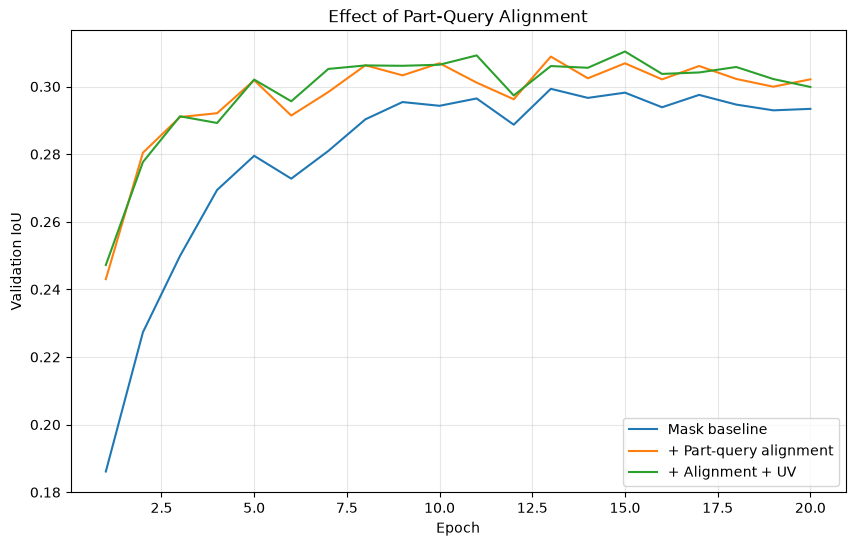

In [114]:
mask_df = pd.DataFrame(
    mask_history
)

alignment_df = pd.DataFrame(
    alignment_history
)

alignment_uv_df = pd.DataFrame(
    alignment_uv_history
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    mask_df["epoch"],
    mask_df["val_iou"],
    label="Mask baseline",
)


plt.plot(
    alignment_df["epoch"],
    alignment_df["val_iou"],
    label="+ Part-query alignment",
)


plt.plot(
    alignment_uv_df["epoch"],
    alignment_uv_df["val_iou"],
    label="+ Alignment + UV",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation IoU"
)

plt.title(
    "Effect of Part-Query Alignment"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

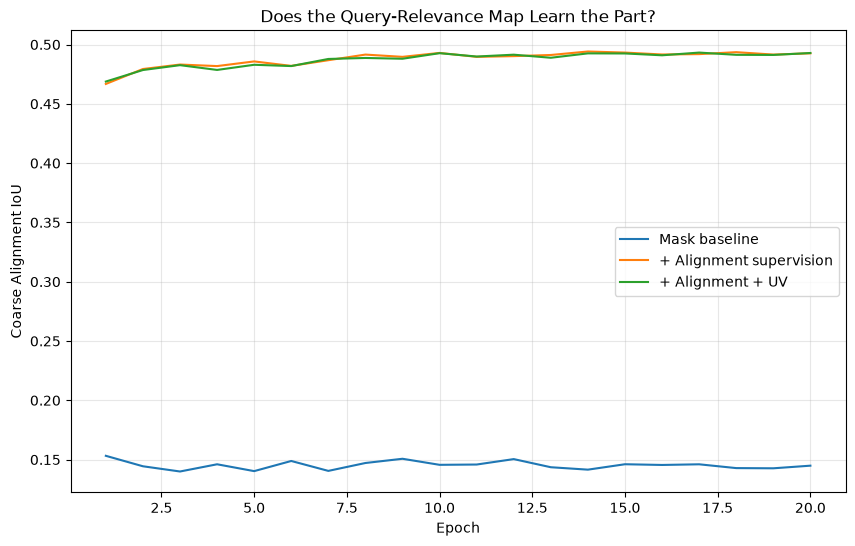

In [115]:
plt.figure(
    figsize=(10, 6)
)


plt.plot(
    mask_df["epoch"],
    mask_df[
        "val_alignment_iou"
    ],
    label="Mask baseline",
)


plt.plot(
    alignment_df["epoch"],
    alignment_df[
        "val_alignment_iou"
    ],
    label="+ Alignment supervision",
)


plt.plot(
    alignment_uv_df["epoch"],
    alignment_uv_df[
        "val_alignment_iou"
    ],
    label="+ Alignment + UV",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Coarse Alignment IoU"
)

plt.title(
    "Does the Query-Relevance Map Learn the Part?"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [116]:
def load_best_model(
    mode,
):

    checkpoint_path = (
        OUTPUT_ROOT
        / mode
        / "best.pt"
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )


    model = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
        .to(DEVICE)
    )


    load_trainable_state(
        model,
        checkpoint,
    )


    model.eval()


    return (
        model,
        checkpoint,
    )

In [117]:
best_mask_model, _ = (
    load_best_model(
        "mask_baseline"
    )
)

best_alignment_model, _ = (
    load_best_model(
        "alignment_mask"
    )
)

best_alignment_uv_model, _ = (
    load_best_model(
        "alignment_relative_uv"
    )
)

In [118]:
@torch.no_grad()
def evaluate_model(
    model,
    mode,
    loader,
):

    return run_epoch(
        model,
        mode,
        loader,
        optimizer=None,
        scaler=None,
    )

In [119]:
mask_seen = evaluate_model(
    best_mask_model,
    "mask_baseline",
    test_seen_loader,
)

mask_unseen = evaluate_model(
    best_mask_model,
    "mask_baseline",
    test_unseen_loader,
)

print("Seen:", mask_seen)
print("Unseen:", mask_unseen)

Seen: {'loss': 0.6513884822008907, 'seg_loss': 0.6513884822008907, 'align_loss': 1.5401332515596602, 'iou': 0.31023710288905276, 'dice': 0.4096567536348124, 'alignment_iou': 0.15992114983125527}
Unseen: {'loss': 0.8298624575814564, 'seg_loss': 0.8298624575814564, 'align_loss': 1.5459030862113117, 'iou': 0.19698158425160345, 'dice': 0.27368578171970565, 'alignment_iou': 0.1518131027568935}


In [120]:
alignment_seen = evaluate_model(
    best_alignment_model,
    "alignment_mask",
    test_seen_loader,
)

alignment_unseen = evaluate_model(
    best_alignment_model,
    "alignment_mask",
    test_unseen_loader,
)

print("Seen:", alignment_seen)
print("Unseen:", alignment_unseen)

Seen: {'loss': 0.7787822883159532, 'seg_loss': 0.6383681255750506, 'align_loss': 0.7020708008676776, 'iou': 0.3187112983982558, 'dice': 0.42009830658742064, 'alignment_iou': 0.5290459193945709}
Unseen: {'loss': 0.8744775573212141, 'seg_loss': 0.7127544507854072, 'align_loss': 0.8086155014110243, 'iou': 0.26892695409653317, 'dice': 0.3656829528670293, 'alignment_iou': 0.4967099174500113}


In [121]:
alignment_uv_seen = evaluate_model(
    best_alignment_uv_model,
    "alignment_relative_uv",
    test_seen_loader,
)

alignment_uv_unseen = evaluate_model(
    best_alignment_uv_model,
    "alignment_relative_uv",
    test_unseen_loader,
)

print(
    "Seen:",
    alignment_uv_seen,
)

print(
    "Unseen:",
    alignment_uv_unseen,
)

Seen: {'loss': 0.7764376922270482, 'seg_loss': 0.6370378940793606, 'align_loss': 0.696998970086339, 'iou': 0.32054424024201117, 'dice': 0.41995316519294495, 'alignment_iou': 0.5316297786591563}
Unseen: {'loss': 0.8739069834032095, 'seg_loss': 0.7141413364705042, 'align_loss': 0.7988282087321239, 'iou': 0.2659079368974342, 'dice': 0.35935166245150235, 'alignment_iou': 0.49942743879699464}


In [122]:
results = pd.DataFrame(
    [
        {
            "model": "Mask baseline",

            "seen_iou": (
                mask_seen["iou"]
            ),

            "seen_dice": (
                mask_seen["dice"]
            ),

            "unseen_iou": (
                mask_unseen["iou"]
            ),

            "unseen_dice": (
                mask_unseen["dice"]
            ),

            "unseen_alignment_iou": (
                mask_unseen[
                    "alignment_iou"
                ]
            ),
        },

        {
            "model": "Part-query alignment",

            "seen_iou": (
                alignment_seen["iou"]
            ),

            "seen_dice": (
                alignment_seen["dice"]
            ),

            "unseen_iou": (
                alignment_unseen["iou"]
            ),

            "unseen_dice": (
                alignment_unseen["dice"]
            ),

            "unseen_alignment_iou": (
                alignment_unseen[
                    "alignment_iou"
                ]
            ),
        },

        {
            "model": (
                "Alignment + Relative UV"
            ),

            "seen_iou": (
                alignment_uv_seen[
                    "iou"
                ]
            ),

            "seen_dice": (
                alignment_uv_seen[
                    "dice"
                ]
            ),

            "unseen_iou": (
                alignment_uv_unseen[
                    "iou"
                ]
            ),

            "unseen_dice": (
                alignment_uv_unseen[
                    "dice"
                ]
            ),

            "unseen_alignment_iou": (
                alignment_uv_unseen[
                    "alignment_iou"
                ]
            ),
        },
    ]
)

results

,model,seen_iou,seen_dice,unseen_iou,unseen_dice,unseen_alignment_iou
0,Mask baseline,0.310237,0.409657,0.196982,0.273686,0.151813
1,Part-query alignment,0.318711,0.420098,0.268927,0.365683,0.496710
2,Alignment + Relative UV,0.320544,0.419953,0.265908,0.359352,0.499427


In [123]:
alignment_gain_seen = (
    alignment_seen["iou"]
    - mask_seen["iou"]
)

alignment_gain_unseen = (
    alignment_unseen["iou"]
    - mask_unseen["iou"]
)


uv_after_alignment_seen = (
    alignment_uv_seen["iou"]
    - alignment_seen["iou"]
)

uv_after_alignment_unseen = (
    alignment_uv_unseen["iou"]
    - alignment_unseen["iou"]
)


print(
    "Alignment gain"
)

print(
    f"Seen:   "
    f"{alignment_gain_seen:+.4f}"
)

print(
    f"Unseen: "
    f"{alignment_gain_unseen:+.4f}"
)


print()


print(
    "Additional UV gain after alignment"
)

print(
    f"Seen:   "
    f"{uv_after_alignment_seen:+.4f}"
)

print(
    f"Unseen: "
    f"{uv_after_alignment_unseen:+.4f}"
)

Alignment gain
Seen:   +0.0085
Unseen: +0.0719

Additional UV gain after alignment
Seen:   +0.0018
Unseen: -0.0030


# Interpretation

## Case A

Alignment > Mask Baseline

Interpretation:

Explicitly learning patch-query correspondence provides useful information
that the original decoder did not learn sufficiently by simply broadcasting
the CLIP embedding.

---

## Case B

Alignment ≈ Mask Baseline

Interpretation:

The segmentation decoder may already be learning the necessary relationship
between DINO features and CLIP text.

The explicit relevance map would therefore add little.

---

## Case C

Alignment > Mask Baseline
and
Alignment + UV > Alignment

Interpretation:

Semantic correspondence and object-relative geometry provide complementary
information.

The alignment branch answers:

"What visually corresponds to this query?"

while U/V answer:

"Where is this region located inside the parent object?"

---

## Case D

Alignment > Mask Baseline
but
Alignment + UV ≈ Alignment

Interpretation:

Once semantic visual-language correspondence is improved, explicit geometry
becomes mostly redundant.

This would strongly support the hypothesis that the major limitation was
visual-language grounding rather than missing spatial coordinates.

In [124]:
@torch.no_grad()
def predict_sample(
    model,
    sample,
):

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    object_mask = (
        sample["object_mask"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_u = (
        sample["relative_u"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_v = (
        sample["relative_v"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    text_embedding = (
        text_encoder(
            [
                sample["query"]
            ]
        )
    )


    logits, aux = model(
        image,
        text_embedding,
        object_mask,
        relative_u,
        relative_v,
    )


    probability = (
        torch.sigmoid(
            logits
        )[0, 0]
        .cpu()
    )


    prediction = (
        probability
        >= MASK_THRESHOLD
    )


    alignment_map = (
        aux[
            "alignment_map"
        ][0, 0]
        .cpu()
    )


    return {
        "probability": probability,

        "prediction": prediction,

        "alignment": (
            alignment_map
        ),
    }

In [125]:
QUALITATIVE_INDEX = 10

sample = (
    test_unseen_dataset[
        QUALITATIVE_INDEX
    ]
)


baseline_output = predict_sample(
    best_mask_model,
    sample,
)


alignment_output = predict_sample(
    best_alignment_model,
    sample,
)


uv_output = predict_sample(
    best_alignment_uv_model,
    sample,
)

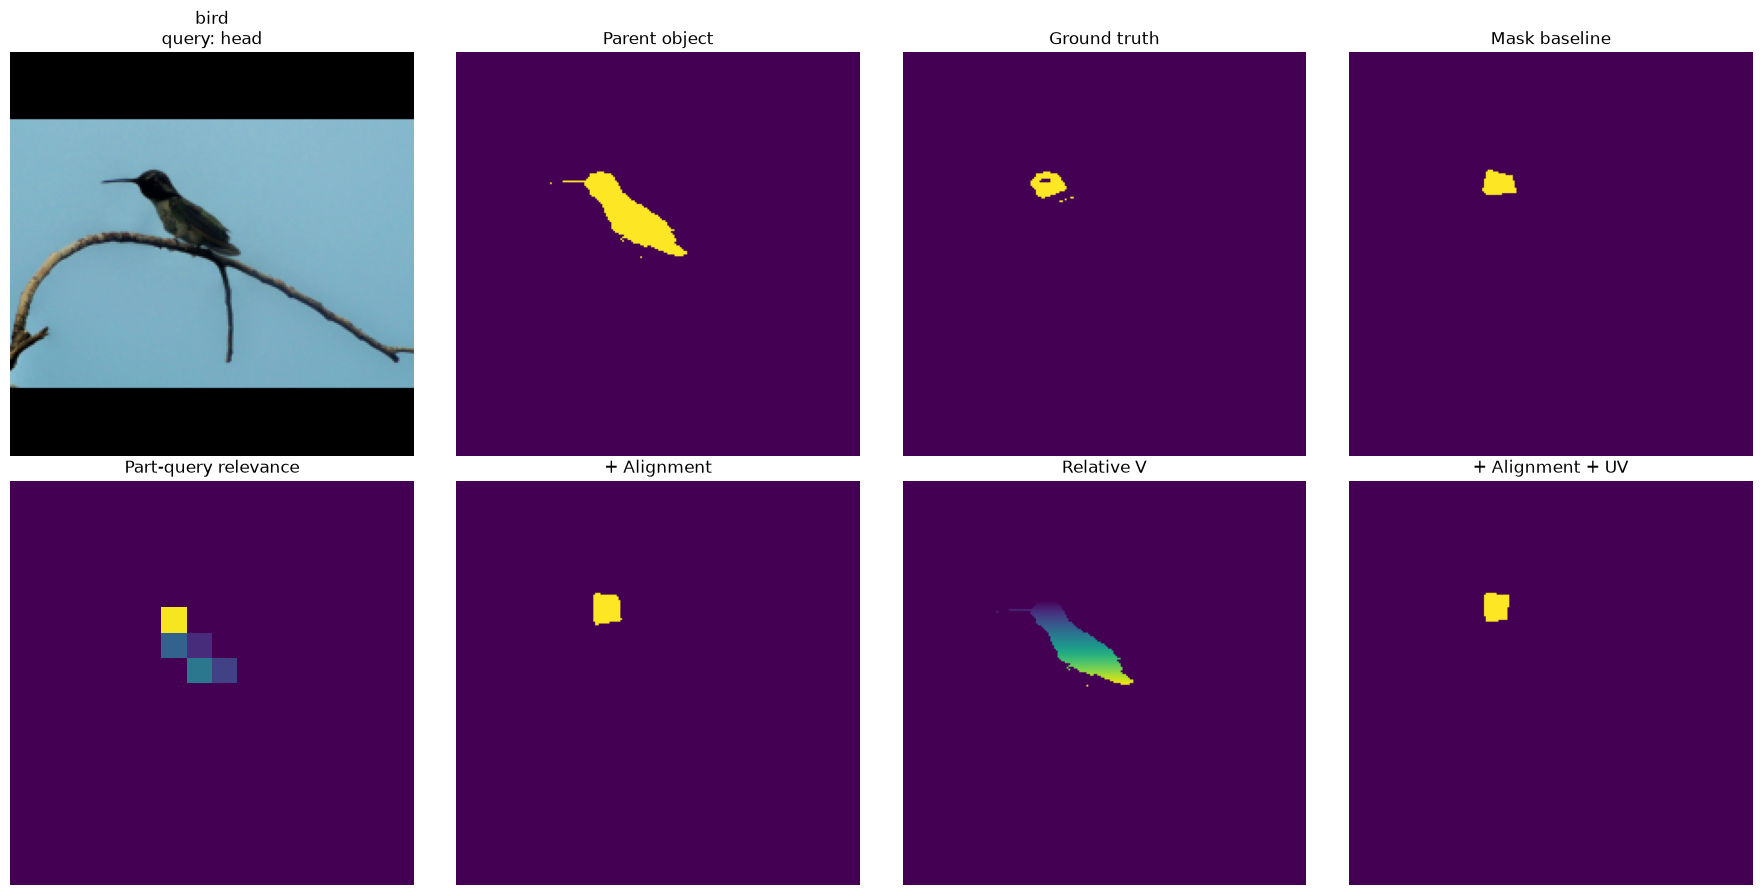

In [126]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
)


axes[0, 0].imshow(
    sample[
        "display_image"
    ]
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    f"{sample['object_name']}\n"
    f"query: {sample['query']}"
)


axes[0, 1].imshow(
    sample[
        "object_mask"
    ].squeeze()
)

axes[0, 1].set_title(
    "Parent object"
)


axes[0, 2].imshow(
    sample[
        "part_mask"
    ].squeeze()
)

axes[0, 2].set_title(
    "Ground truth"
)


axes[0, 3].imshow(
    baseline_output[
        "prediction"
    ]
)

axes[0, 3].set_title(
    "Mask baseline"
)


axes[1, 0].imshow(
    alignment_output[
        "alignment"
    ],
    vmin=0,
    vmax=1,
)

axes[1, 0].set_title(
    "Part-query relevance"
)


axes[1, 1].imshow(
    alignment_output[
        "prediction"
    ]
)

axes[1, 1].set_title(
    "+ Alignment"
)


axes[1, 2].imshow(
    sample[
        "relative_v"
    ].squeeze(),
    vmin=0,
    vmax=1,
)

axes[1, 2].set_title(
    "Relative V"
)


axes[1, 3].imshow(
    uv_output[
        "prediction"
    ]
)

axes[1, 3].set_title(
    "+ Alignment + UV"
)


for ax in axes.flat:

    ax.axis("off")


plt.tight_layout()
plt.show()

In [127]:
alignment_high = F.interpolate(
    alignment_output[
        "alignment"
    ][None, None],
    size=(
        IMAGE_SIZE,
        IMAGE_SIZE,
    ),
    mode="bilinear",
    align_corners=False,
)[0, 0]

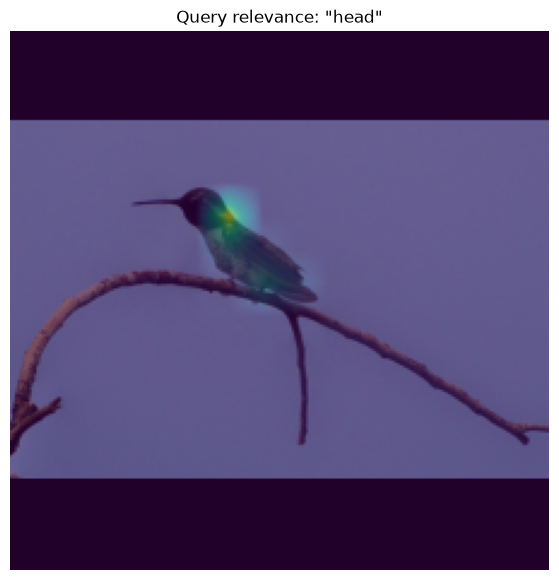

In [128]:
plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    sample[
        "display_image"
    ]
    .permute(1, 2, 0)
)

plt.imshow(
    alignment_high,
    alpha=0.5,
    vmin=0,
    vmax=1,
)

plt.title(
    f'Query relevance: "{sample["query"]}"'
)

plt.axis("off")

plt.show()

In [129]:
queries_to_test = [
    "head",
    "leg",
    "wheel",
    "tail",
]

In [130]:
@torch.no_grad()
def alignment_for_query(
    model,
    sample,
    query,
):

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    object_mask = (
        sample["object_mask"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_u = (
        sample["relative_u"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_v = (
        sample["relative_v"]
        .unsqueeze(0)
        .to(DEVICE)
    )


    text = text_encoder(
        [query]
    )


    _, aux = model(
        image,
        text,
        object_mask,
        relative_u,
        relative_v,
    )


    return (
        aux[
            "alignment_map"
        ][0, 0]
        .cpu()
    )

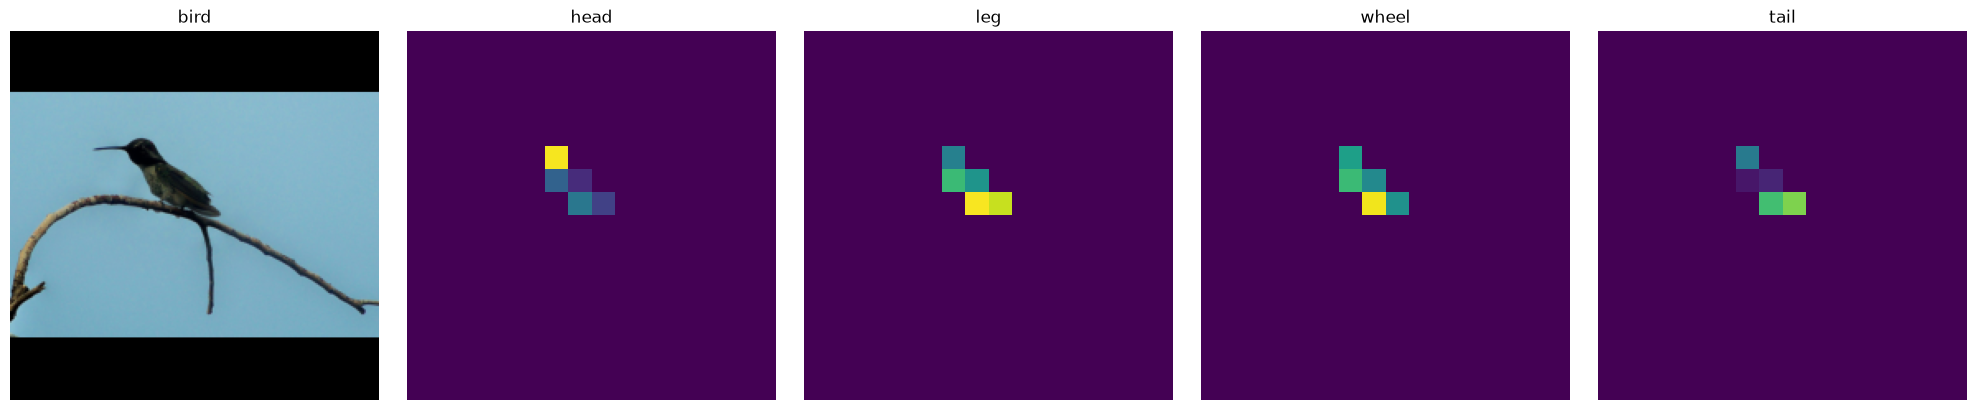

In [131]:
fig, axes = plt.subplots(
    1,
    len(queries_to_test) + 1,
    figsize=(20, 4),
)


axes[0].imshow(
    sample[
        "display_image"
    ]
    .permute(1, 2, 0)
)

axes[0].set_title(
    sample[
        "object_name"
    ]
)


for i, query in enumerate(
    queries_to_test,
    start=1,
):

    relevance = alignment_for_query(
        best_alignment_model,
        sample,
        query,
    )


    axes[i].imshow(
        relevance,
        vmin=0,
        vmax=1,
    )

    axes[i].set_title(
        query
    )


for ax in axes:

    ax.axis("off")


plt.tight_layout()
plt.show()

In [132]:
results_path = (
    OUTPUT_ROOT
    / "alignment_results.csv"
)

results.to_csv(
    results_path,
    index=False,
)

print(
    "Saved:",
    results_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/part_query_alignment/alignment_results.csv


In [133]:
summary = {
    "mask_baseline": {
        "seen": mask_seen,
        "unseen": mask_unseen,
    },

    "alignment_mask": {
        "seen": alignment_seen,
        "unseen": alignment_unseen,
    },

    "alignment_relative_uv": {
        "seen": alignment_uv_seen,
        "unseen": alignment_uv_unseen,
    },

    "alignment_gain": {
        "seen": alignment_gain_seen,
        "unseen": alignment_gain_unseen,
    },

    "uv_gain_after_alignment": {
        "seen": (
            uv_after_alignment_seen
        ),

        "unseen": (
            uv_after_alignment_unseen
        ),
    },
}


with open(
    OUTPUT_ROOT
    / "alignment_summary.json",
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

# Notebook 06 Summary

This notebook introduced a lightweight explicit connection between frozen
DINOv2 visual features and frozen CLIP part-query embeddings.

## Original Approach

DINO:

[B, 384, 16, 16]

CLIP:

[B, 512]

The CLIP representation was broadcast spatially and the decoder had to learn
visual-language correspondence implicitly.

---

## Part-Query Alignment

Both DINO and CLIP representations are projected into a shared
128-dimensional space.

For every DINO patch:

cosine(
    projected DINO patch,
    projected CLIP query
)

is computed.

This creates:

[B, 1, 16, 16]

query-relevance maps.

---

## Auxiliary Supervision

The ground-truth part mask is converted from:

224 × 224

to:

16 × 16

using adaptive max pooling.

This preserves tiny positive regions.

The relevance map is supervised using:

Alignment BCE + Alignment Dice

only inside the parent-object region.

---

## Experiments

### Mask Baseline

DINO + CLIP + parent-object mask

### Part-Query Alignment

DINO + CLIP + parent-object mask + query relevance map

### Alignment + Relative UV

DINO + CLIP + parent-object mask + query relevance + object-relative U/V

---

## Main Conclusions to Extract

Alignment vs Mask Baseline

→ Does explicit visual-language correspondence improve segmentation?

Alignment + UV vs Alignment

→ Does object-relative geometry remain complementary after semantic
grounding is improved?

Alignment heatmaps

→ Can we visually explain where the model searches for the requested part?

Seen vs Unseen

→ Does semantic alignment improve transfer to unseen parent-object
categories?